# Maritime SSL — Pipeline Complet
### AIS → Scènes → Séquences → Transformer SSL → Embeddings → Clustering

**Pipeline en 7 étapes :**
1. Chargement & nettoyage AIS + tables de référence
2. Construction des scènes maritimes (5 min, 49D, ego+env+voisins)
3. Construction des séquences temporelles par navire (contexte 2 min → horizon 5 min)
4. Entraînement SSL : Transformer encodeur-décodeur (prédiction de trajectoire)
5. Extraction des embeddings (encodeur) enrichis des features de scène
6. Clustering HDBSCAN sur les embeddings enrichis
7. Détection d'anomalies

**Structure du répertoire :**
```
.
├── maritime_ssl_transformer_COMPLETE.ipynb
└── data/
    ├── AIS_DATA/
    │   ├── nari_dynamic.csv
    │   └── nari_static.csv
    ├── AIS_Status/
    │   ├── Navigational Status.csv
    │   └── Ship Types List.csv
    ├── OCEAN_DATA/
    │   └── oc_*.csv
    └── WEATHER_DATA/
        ├── table_weatherStation.csv
        ├── table_wheatherObservation.csv
        └── table_windDirection.csv
```


## 1. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict
from scipy.spatial import cKDTree
import warnings, math, time
warnings.filterwarnings("ignore")

# ─── Chemins ──────────────────────────────────────────────────────────────────
DATA_ROOT      = Path("")
AIS_DIR        = DATA_ROOT / "AIS_DATA"
AIS_STATUS_DIR = DATA_ROOT / "AIS_Status"
OCEAN_DIR      = DATA_ROOT / "OCEAN_DATA"
WEATHER_DIR    = DATA_ROOT / "WEATHER_DATA"
OUT_DIR        = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

# ─── Paramètres scènes ────────────────────────────────────────────────────────
SCENE_DURATION_MIN = 5
SCENE_RADIUS_NM    = 5
N_NEIGHBORS        = 3

# ─── Paramètres séquences SSL ─────────────────────────────────────────────────
AIS_INTERVAL_S  = 10
STRIDE_SEQS    = 3 
CONTEXT_MIN     = 2
HORIZON_MIN     = 5
CONTEXT_STEPS   = int(CONTEXT_MIN * 60 / AIS_INTERVAL_S)    # 12 points
HORIZON_STEPS   = int(HORIZON_MIN * 60 / AIS_INTERVAL_S)    # 30 points
MAX_GAP_S       = 60     # gap max entre deux points consécutifs avant coupure

# ─── Dimensions séquence ──────────────────────────────────────────────────────
# Chaque point = [Δlat, Δlon, speed_kt, sin_cog, cos_cog, turn_rate_dpm, nav_status_group]
INPUT_DIM  = 7
TARGET_DIM = 5   # [Δlat, Δlon, speed_kt, sin_cog, cos_cog]

# ─── Architecture Transformer ─────────────────────────────────────────────────
D_MODEL      = 64
N_HEADS      = 4
N_ENC_LAYERS = 2
N_DEC_LAYERS = 2
D_FF         = 128
DROPOUT      = 0.1
EMBED_DIM    = D_MODEL   # dimension des embeddings extraits

# ─── Entraînement ─────────────────────────────────────────────────────────────
BATCH_SIZE   = 64
EPOCHS       = 50
LR           = 1e-3
PATIENCE     = 5
NROWS_AIS    = 500_000   # None pour tout charger

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Configuration OK")
print(f"   Contexte  : {CONTEXT_STEPS} points ({CONTEXT_MIN} min)")
print(f"   Horizon   : {HORIZON_STEPS} points ({HORIZON_MIN} min)")
print(f"   Input dim : {INPUT_DIM}D par point")
print(f"   Embed dim : {EMBED_DIM}D")
print(f"   Device    : {DEVICE}")


✅ Configuration OK
   Contexte  : 12 points (2 min)
   Horizon   : 30 points (5 min)
   Input dim : 7D par point
   Embed dim : 64D
   Device    : cpu


## 2. Tables de référence AIS

In [2]:
# ─── Navigational Status (depuis Navigational Status.csv) ─────────────────────
NAV_STATUS_MAP = {
    0: 0,   # under way using engine  → underway
    8: 0,   # under way sailing       → underway
    1: 1,   # at anchor               → anchored
    5: 1,   # moored                  → anchored
    7: 2,   # engaged in fishing      → fishing
    2: 3,   # not under command       → restricted
    3: 3,   # restricted manoeuvrability
    4: 3,   # constrained by draught
    6: 3,   # aground
    14: 4,  # AIS-SART active         → emergency
    15: 5,  # not defined             → unknown
}
for c in range(9, 14): NAV_STATUS_MAP[c] = 5

NAV_GROUP_LABELS = {
    0: "underway", 1: "anchored", 2: "fishing",
    3: "restricted", 4: "emergency", 5: "unknown"
}

# ─── Ship Types (depuis Ship Types List.csv) ──────────────────────────────────
SHIP_TYPE_RANGES = [
    (30, 39, "fishing"),
    (70, 79, "cargo"),
    (80, 89, "tanker"),
    (60, 69, "passenger"),
    (40, 49, "fast"),
    (50, 59, "service"),
    (20, 29, "special"),
    (90, 99, "other"),
]
SHIP_CAT_CODE = {
    "fishing": 0, "cargo": 1, "tanker": 2, "passenger": 3,
    "fast": 4, "service": 5, "special": 6, "other": 7, "unknown": 8
}

def get_ship_category(shiptype) -> str:
    if pd.isna(shiptype): return "unknown"
    v = int(shiptype)
    for lo, hi, cat in SHIP_TYPE_RANGES:
        if lo <= v <= hi: return cat
    return "unknown"

print("✅ Tables AIS prêtes")
print(f"   {len(NAV_STATUS_MAP)} codes de statut → 6 groupes")
print(f"   {len(SHIP_TYPE_RANGES)} ranges de ship type → 9 catégories")


✅ Tables AIS prêtes
   16 codes de statut → 6 groupes
   8 ranges de ship type → 9 catégories


## 3. Chargement & nettoyage AIS

In [3]:
print("⏳ Chargement nari_dynamic.csv ...")

ais_raw = pd.read_csv(
    AIS_DIR / "nari_dynamic.csv",
    nrows=NROWS_AIS,
    dtype={
        "sourcemmsi":         "Int64",
        "navigationalstatus": "Int8",
        "rateofturn":         "float32",
        "speedoverground":    "float32",
        "courseoverground":   "float32",
        "trueheading":        "float32",   # ← float32 directement, plus Int16
        "lon":                "float32",
        "lat":                "float32",
        "t":                  "int64",
    }
)

ais_raw = ais_raw.rename(columns={
    "sourcemmsi":         "mmsi",
    "navigationalstatus": "status",
    "rateofturn":         "turn_raw",
    "speedoverground":    "speed_kt",
    "courseoverground":   "course_deg",
    "trueheading":        "heading_deg",
})
ais_raw["timestamp"] = pd.to_datetime(ais_raw["t"], unit="s", utc=True)
ais_raw = ais_raw.drop(columns=["t"])

# ─── Nettoyage ────────────────────────────────────────────────────────────────
n0 = len(ais_raw)
ais = ais_raw[
    ais_raw["lon"].between(-10.0, 0.0) &
    ais_raw["lat"].between(45.0, 51.0) &
    ais_raw["speed_kt"].between(0, 50) &
    ais_raw["course_deg"].between(0, 360) &
    ais_raw["mmsi"].between(100_000_000, 799_999_999)
].copy()
ais = ais.dropna(subset=["lat", "lon", "speed_kt", "course_deg"])
ais = ais.drop_duplicates(subset=["mmsi", "timestamp"])

# heading_deg : valeur 511 = non disponible dans le standard AIS → remplacer par course_deg
ais["heading_deg"] = (
    ais["heading_deg"]
    .fillna(ais["course_deg"])                          # NaN → course_deg
    .where(ais["heading_deg"].between(0, 359),          # hors [0,359] → course_deg
           other=ais["course_deg"].values)              # .values évite le conflit d'index
    .astype("float32")
)

# ─── Statut de navigation ─────────────────────────────────────────────────────
ais["nav_group"] = ais["status"].map(NAV_STATUS_MAP).fillna(5).astype(int)

# ─── Données statiques ────────────────────────────────────────────────────────
print("⏳ Chargement nari_static.csv ...")
static_raw = pd.read_csv(
    AIS_DIR / "nari_static.csv",
    dtype={"sourcemmsi": "Int64", "shiptype": "Int16"},
    low_memory=False
)
static_raw["timestamp"] = pd.to_datetime(static_raw["t"], unit="s", utc=True)
static = (
    static_raw.rename(columns={"sourcemmsi": "mmsi"})
    .sort_values("timestamp")
    .drop_duplicates("mmsi", keep="last")
    [["mmsi", "shiptype", "shipname"]]
)
static["ship_category"]      = static["shiptype"].apply(get_ship_category)
static["ship_category_code"] = static["ship_category"].map(SHIP_CAT_CODE).fillna(8).astype(int)

ais = ais.merge(static[["mmsi", "ship_category", "ship_category_code"]], on="mmsi", how="left")
ais["ship_category"]      = ais["ship_category"].fillna("unknown")
ais["ship_category_code"] = ais["ship_category_code"].fillna(8).astype(int)

ais = ais.sort_values(["mmsi", "timestamp"]).reset_index(drop=True)

print(f"✅ {n0:,} → {len(ais):,} messages  ({ais['mmsi'].nunique():,} navires)")
print(f"   Période : {ais['timestamp'].min()} → {ais['timestamp'].max()}")
print()
print("Nav groups :", ais["nav_group"].map(NAV_GROUP_LABELS).value_counts().to_dict())
print("Ship cats  :", ais["ship_category"].value_counts().head(5).to_dict())

⏳ Chargement nari_dynamic.csv ...
⏳ Chargement nari_static.csv ...
✅ 500,000 → 497,176 messages  (209 navires)
   Période : 2015-09-30 22:00:02+00:00 → 2015-10-07 02:53:47+00:00

Nav groups : {'underway': 283065, 'unknown': 177318, 'fishing': 16795, 'anchored': 14093, 'restricted': 5905}
Ship cats  : {'passenger': 172030, 'fishing': 141175, 'service': 75506, 'cargo': 53241, 'unknown': 37689}


## 4. Fonctions géométriques

In [4]:
def haversine_nm(lat1, lon1, lat2, lon2) -> float:
    R = 3440.065
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    a = (np.sin(np.radians(lat2-lat1)/2)**2
         + np.cos(phi1)*np.cos(phi2)*np.sin(np.radians(lon2-lon1)/2)**2)
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

def bearing_deg(lat1, lon1, lat2, lon2) -> float:
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dlam = np.radians(lon2 - lon1)
    x = np.sin(dlam) * np.cos(phi2)
    y = np.cos(phi1)*np.sin(phi2) - np.sin(phi1)*np.cos(phi2)*np.cos(dlam)
    return (np.degrees(np.arctan2(x, y)) + 360) % 360

def course_to_vector(course_deg, speed_kt):
    r = np.radians(course_deg)
    return speed_kt*np.sin(r), speed_kt*np.cos(r)

def compute_cpa_tcpa(lat_e, lon_e, spd_e, cog_e, lat_n, lon_n, spd_n, cog_n):
    dlat = (lat_n - lat_e) * 60.0
    dlon = (lon_n - lon_e) * 60.0 * np.cos(np.radians((lat_e+lat_n)/2))
    vx_e, vy_e = course_to_vector(cog_e, spd_e)
    vx_n, vy_n = course_to_vector(cog_n, spd_n)
    dvx, dvy   = vx_n-vx_e, vy_n-vy_e
    dot_rv = dlon*dvx + dlat*dvy
    dot_vv = dvx**2 + dvy**2
    tcpa_h = (-dot_rv/dot_vv) if dot_vv > 1e-9 else 0.0
    t_h    = max(0.0, tcpa_h)
    cpa_nm = np.sqrt((dlon+dvx*t_h)**2 + (dlat+dvy*t_h)**2)
    return float(cpa_nm), float(tcpa_h*60)

def collision_risk_score(cpa_nm, tcpa_min):
    if tcpa_min < 0 or tcpa_min > 60: return 0.0
    return float(np.clip(np.exp(-cpa_nm/0.5) * np.exp(-tcpa_min/15.0), 0, 1))

print("✅ Fonctions géométriques OK")


✅ Fonctions géométriques OK


## 5. Chargement des données environnementales

In [5]:
MONTH_FILES = {
    "october": "oc_october.csv", "november": "oc_november.csv",
    "december": "oc_december.csv", "january": "oc_january.csv",
    "february": "oc_february.csv", "march": "oc_march.csv",
}

print("⏳ Chargement données océaniques ...")
ocean_chunks = []
for month, fname in MONTH_FILES.items():
    fpath = OCEAN_DIR / fname
    if not fpath.exists(): print(f"   ⚠️  {fname} absent"); continue
    chunk = pd.read_csv(fpath, usecols=["lat","lon","hs","dir","wlv","ts"],
                        dtype={"lat":"float32","lon":"float32","hs":"float32",
                               "dir":"float32","wlv":"float32","ts":"int64"},
                        low_memory=False)
    chunk["timestamp"] = pd.to_datetime(chunk["ts"], unit="s", utc=True)
    chunk = chunk.drop(columns=["ts"]).dropna(subset=["hs"])
    ocean_chunks.append(chunk)
    print(f"   ✅ {month} : {len(chunk):,} lignes")

ocean = pd.concat(ocean_chunks, ignore_index=True).sort_values("timestamp")
ocean["t_hour"] = ocean["timestamp"].values.astype("int64") // (3_600*1_000_000_000)

print("⏳ Construction KD-trees océaniques ...")
ocean_trees = {}
for t_h, grp in ocean.groupby("t_hour"):
    ocean_trees[t_h] = (cKDTree(grp[["lat","lon"]].values), grp.reset_index(drop=True))
ocean_hours = sorted(ocean_trees.keys())
print(f"✅ {len(ocean_trees)} snapshots océaniques indexés")

print("⏳ Chargement données météo ...")

# table_weatherStation.csv → colonnes : id_station, station_name, latitude, longitude, elevation
stations = pd.read_csv(WEATHER_DIR / "table_weatherStation.csv")
stations = stations.rename(columns={"latitude": "lat", "longitude": "lon"})

# table_windDirection.csv → colonnes : id_windDirection, DD_num, DD_plainText, DD_shortText
# DD_num contient les degrés (0–360)
wind_dir = pd.read_csv(WEATHER_DIR / "table_windDirection.csv")
wind_dir = wind_dir.rename(columns={"DD_num": "wind_dir_deg"})

# table_wheatherObservation.csv → colonnes : id_station, local_time, T, Tn, Tx, P, U,
#                                            id_windDirection, Ff, ff10, ff3, VV, Td, RRR, tR
obs_raw = pd.read_csv(
    WEATHER_DIR / "table_wheatherObservation.csv",
    dtype={"id_station": "int16", "local_time": "int64"},
    low_memory=False
)
obs_raw["timestamp"] = pd.to_datetime(obs_raw["local_time"], unit="s", utc=True)

# Jointure direction du vent (DD_num → degrés)
obs_raw = obs_raw.merge(
    wind_dir[["id_windDirection", "wind_dir_deg"]],
    on="id_windDirection", how="left"
)

# Jointure position des stations (latitude/longitude renommés en lat/lon)
obs = obs_raw.merge(
    stations[["id_station", "lat", "lon"]],
    on="id_station", how="left"
)

# Vitesse vent m/s → nœuds
obs["wind_kt"] = obs["Ff"] * 1.944
obs["t_hour"]  = obs["timestamp"].values.astype("int64") // (3_600*1_000_000_000)

# KD-tree sur les positions des stations
station_coords = obs[["lat", "lon"]].drop_duplicates().dropna().reset_index(drop=True)
station_tree   = cKDTree(station_coords.values)
print(f"✅ {len(stations)} stations météo indexées")

# ─── Ports ────────────────────────────────────────────────────────────────────
ports_df = pd.DataFrame([
    {"name":"Brest",         "lat":48.383,"lon":-4.496},
    {"name":"Lorient",       "lat":47.750,"lon":-3.367},
    {"name":"Saint-Nazaire", "lat":47.267,"lon":-2.200},
    {"name":"Nantes",        "lat":47.216,"lon":-1.553},
    {"name":"La Rochelle",   "lat":46.160,"lon":-1.151},
    {"name":"Bordeaux",      "lat":44.837,"lon":-0.574},
    {"name":"Roscoff",       "lat":48.726,"lon":-3.987},
    {"name":"Saint-Malo",    "lat":48.650,"lon":-2.017},
])
port_tree = cKDTree(ports_df[["lat","lon"]].values)

# ─── Lookup functions ─────────────────────────────────────────────────────────
def ocean_lookup(lat, lon, t):
    t_h = t.value // (3_600*1_000_000_000)
    idx = min(max(np.searchsorted(ocean_hours, t_h), 0), len(ocean_hours)-1)
    tree, grp = ocean_trees[ocean_hours[idx]]
    _, i = tree.query([lat, lon])
    row  = grp.iloc[i]
    return {"hs_m": float(row.get("hs", np.nan)),
            "wave_dir_deg": float(row.get("dir", np.nan))}

def weather_lookup(lat, lon, t):
    _, si          = station_tree.query([lat, lon])
    nr_lat, nr_lon = station_coords.iloc[si]
    t_h            = t.value // (3_600*1_000_000_000)
    sub = obs[(obs["lat"] == nr_lat) & (obs["lon"] == nr_lon)]
    if len(sub) == 0:
        return {"wind_kt": np.nan, "wind_dir_deg": np.nan, "visibility_km": np.nan}
    best = (sub["t_hour"] - t_h).abs().idxmin()
    row  = sub.loc[best]
    return {
        "wind_kt":       float(row.get("wind_kt",     np.nan)),
        "wind_dir_deg":  float(row.get("wind_dir_deg",np.nan)),
        "visibility_km": float(row.get("VV",          np.nan)),
    }

def dist_to_port(lat, lon):
    _, i = port_tree.query([lat, lon])
    row  = ports_df.iloc[i]
    return haversine_nm(lat, lon, row["lat"], row["lon"]), row["name"]

print("✅ Fonctions de lookup prêtes")
test_t = pd.Timestamp("2015-11-15 10:00:00", tz="UTC")
oc = ocean_lookup(48.4, -4.5, test_t)
wx = weather_lookup(48.4, -4.5, test_t)
print(f"   Test → hs={oc['hs_m']:.2f}m  vent={wx['wind_kt']:.1f}kt")

⏳ Chargement données océaniques ...
   ✅ october : 13,511,288 lignes
   ✅ november : 13,075,440 lignes
   ✅ december : 13,456,807 lignes
   ✅ january : 13,075,440 lignes
   ✅ february : 12,639,592 lignes
   ✅ march : 13,511,288 lignes
⏳ Construction KD-trees océaniques ...
✅ 1 snapshots océaniques indexés
⏳ Chargement données météo ...
✅ 16 stations météo indexées
✅ Fonctions de lookup prêtes
   Test → hs=-65.53m  vent=11.7kt


## 6. Structures de données pour les scènes

In [6]:
@dataclass
class EgoFeatures:
    mean_speed_kt:       float
    std_speed_kt:        float
    mean_course_deg:     float
    mean_turn_rate_dpm:  float
    total_distance_nm:   float
    acceleration_kt_min: float
    behavior_code:       int

@dataclass
class NeighborFeatures:
    rel_bearing_deg:     float
    distance_nm:         float
    rel_speed_kt:        float
    rel_course_diff_deg: float
    cpa_nm:              float
    tcpa_min:            float
    collision_risk:      float

@dataclass
class EnvFeatures:
    dist_coast_nm:        float
    dist_nearest_port_nm: float
    port_name:            str
    in_tss:               bool
    in_anchorage:         bool
    wind_kt:              float = float("nan")
    wind_dir_deg:         float = float("nan")
    wave_height_m:        float = float("nan")
    visibility_km:        float = float("nan")

@dataclass
class MaritimeScene:
    scene_id:  str
    mmsi:      int
    t_center:  pd.Timestamp
    ego:       EgoFeatures
    neighbors: List[NeighborFeatures]
    env:       EnvFeatures
    label:     Optional[str] = None

# ─── Comportements ────────────────────────────────────────────────────────────
BEHAVIOR_LABELS = {
    0:"ancré/amarré", 1:"dérive", 2:"manœuvre",
    3:"transit lent", 4:"transit", 5:"pêche/chalutage", 6:"restreint"
}

def classify_behavior(mean_speed, mean_turn, dist_coast, nav_group, ship_category):
    if nav_group == "anchored":   return 0
    if nav_group == "fishing":    return 5
    if nav_group == "restricted": return 6
    if mean_speed < 0.5:  return 0
    if mean_speed < 3.0:
        if mean_turn > 3.0 and (np.isnan(dist_coast) or dist_coast < 10):
            return 5
        return 2 if mean_turn > 3.0 else 1
    if mean_turn > 3.0: return 2
    if ship_category == "fishing" and mean_speed < 6.0: return 5
    return 3 if mean_speed < 8.0 else 4

print("✅ Dataclasses et classificateur OK")


✅ Dataclasses et classificateur OK


## 7. Construction des scènes maritimes (5 min, 49D)

Chaque scène est centrée sur un navire focal à `t_center` :
- **Ego** : 13 features calculées sur ±2.5 min
- **Env** : 9 features (distance côte/port, météo, vagues)
- **3 voisins** : 9 features chacun (CPA, TCPA, risque collision)


In [7]:
def extract_ego_features(track, env, nav_group="unknown", ship_category="unknown"):
    track   = track.sort_values("timestamp").reset_index(drop=True)
    speeds  = track["speed_kt"].values.astype(float)
    courses = track["course_deg"].values.astype(float)
    if "nav_group" in track.columns:
        nav_group     = track["nav_group"].map(NAV_GROUP_LABELS).mode().iloc[0]                         if len(track) else "unknown"
    if "ship_category" in track.columns:
        ship_category = track["ship_category"].iloc[0] if len(track) else "unknown"
    dt_min     = track["timestamp"].diff().dt.total_seconds().fillna(0).values / 60.0
    dcourse    = (np.diff(courses)+180)%360-180
    turn_rates = np.abs(dcourse) / np.maximum(dt_min[1:], 1e-3)
    accel      = np.diff(speeds)  / np.maximum(dt_min[1:], 1e-3)
    lats, lons = track["lat"].values, track["lon"].values
    dists      = [haversine_nm(lats[i],lons[i],lats[i+1],lons[i+1]) for i in range(len(lats)-1)]
    mean_cog   = float(np.degrees(np.arctan2(
        np.mean(np.sin(np.radians(courses))),
        np.mean(np.cos(np.radians(courses))))) % 360)
    mean_spd   = float(np.mean(speeds))
    mean_turn  = float(np.mean(turn_rates)) if len(turn_rates) else 0.0
    beh = classify_behavior(mean_spd, mean_turn, env.dist_coast_nm, nav_group, ship_category)
    return EgoFeatures(
        mean_speed_kt=mean_spd, std_speed_kt=float(np.std(speeds)),
        mean_course_deg=mean_cog, mean_turn_rate_dpm=mean_turn,
        total_distance_nm=float(np.sum(dists)),
        acceleration_kt_min=float(np.mean(accel)) if len(accel) else 0.0,
        behavior_code=beh)

def extract_neighbor_features(e_lat, e_lon, e_spd, e_cog,
                               n_lat, n_lon, n_spd, n_cog):
    dist = haversine_nm(e_lat, e_lon, n_lat, n_lon)
    brg  = bearing_deg(e_lat, e_lon, n_lat, n_lon)
    dcrs = abs(e_cog - n_cog) % 360
    if dcrs > 180: dcrs = 360 - dcrs
    vx_e, vy_e = course_to_vector(e_cog, e_spd)
    vx_n, vy_n = course_to_vector(n_cog, n_spd)
    brg_r = np.radians(brg)
    closing = -((vx_n-vx_e)*np.sin(brg_r) + (vy_n-vy_e)*np.cos(brg_r))
    cpa, tcpa = compute_cpa_tcpa(e_lat,e_lon,e_spd,e_cog, n_lat,n_lon,n_spd,n_cog)
    return NeighborFeatures(
        rel_bearing_deg=float(brg), distance_nm=float(dist),
        rel_speed_kt=float(closing), rel_course_diff_deg=float(dcrs),
        cpa_nm=float(cpa), tcpa_min=float(tcpa),
        collision_risk=collision_risk_score(cpa, tcpa))

def env_lookup(mmsi, lat, lon, t):
    d_port, p_name = dist_to_port(lat, lon)
    oc = ocean_lookup(lat, lon, t)
    wx = weather_lookup(lat, lon, t)
    return EnvFeatures(
        dist_coast_nm=np.nan,
        dist_nearest_port_nm=d_port, port_name=p_name,
        in_tss=False, in_anchorage=False,
        wind_kt=wx["wind_kt"], wind_dir_deg=wx["wind_dir_deg"],
        wave_height_m=oc["hs_m"], visibility_km=wx["visibility_km"])

def build_scene(focal_mmsi, t_center, ais_window):
    half  = pd.Timedelta(minutes=SCENE_DURATION_MIN/2)
    ego_track = ais_window[ais_window["mmsi"]==focal_mmsi]
    if len(ego_track) < 2: return None
    ego_mid  = ego_track.iloc[len(ego_track)//2]
    e_lat, e_lon = float(ego_mid["lat"]), float(ego_mid["lon"])
    e_spd, e_cog = float(ego_mid["speed_kt"]), float(ego_mid["course_deg"])
    env      = env_lookup(focal_mmsi, e_lat, e_lon, t_center)
    ego_feat = extract_ego_features(ego_track, env)
    others   = ais_window[ais_window["mmsi"] != focal_mmsi].copy()
    nb_snap  = (others.groupby("mmsi").apply(lambda g: g.iloc[len(g)//2])
                .reset_index(level=0, drop=False).reset_index(drop=True))
    if "mmsi" not in nb_snap.columns: nb_snap = nb_snap.reset_index()
    if len(nb_snap):
        nb_snap["_d"] = nb_snap.apply(
            lambda r: haversine_nm(e_lat, e_lon, r["lat"], r["lon"]), axis=1)
        nb_snap = nb_snap[nb_snap["_d"]<=SCENE_RADIUS_NM].sort_values("_d").head(N_NEIGHBORS)
    nb_feats = []
    for _, row in nb_snap.iterrows():
        nb_feats.append(extract_neighbor_features(
            e_lat, e_lon, e_spd, e_cog,
            float(row["lat"]), float(row["lon"]),
            float(row["speed_kt"]), float(row["course_deg"])))
    return MaritimeScene(
        scene_id=f"{focal_mmsi}_{t_center.strftime('%Y%m%dT%H%M%S')}",
        mmsi=int(focal_mmsi), t_center=t_center,
        ego=ego_feat, neighbors=nb_feats, env=env)

print("✅ Fonctions de construction de scènes OK")


✅ Fonctions de construction de scènes OK


## 8. Vecteur de scène 49D

In [8]:
EGO_NAMES = [
    "ego_mean_speed_kt","ego_std_speed_kt",
    "ego_mean_course_sin","ego_mean_course_cos",
    "ego_mean_turn_rate_dpm","ego_total_distance_nm",
    "ego_acceleration_kt_min",
    "ego_beh_0","ego_beh_1","ego_beh_2","ego_beh_3","ego_beh_4","ego_beh_5",
]
ENV_NAMES = [
    "env_dist_coast_nm","env_dist_port_nm","env_in_tss","env_in_anchorage",
    "env_wind_kt","env_wind_dir_sin","env_wind_dir_cos",
    "env_wave_height_m","env_visibility_km",
]
_NB_T = ["nb{i}_present","nb{i}_bearing_sin","nb{i}_bearing_cos",
         "nb{i}_distance_nm","nb{i}_rel_speed_kt","nb{i}_course_diff_deg",
         "nb{i}_cpa_nm","nb{i}_tcpa_min","nb{i}_collision_risk"]
NB_NAMES = [t.format(i=i) for i in range(N_NEIGHBORS) for t in _NB_T]
ALL_SCENE_NAMES = EGO_NAMES + ENV_NAMES + NB_NAMES

def scene_to_vector(s: MaritimeScene) -> np.ndarray:
    e = s.ego
    beh = [0.]*6
    if 0 <= e.behavior_code < 6: beh[e.behavior_code] = 1.
    ego_v = [e.mean_speed_kt, e.std_speed_kt,
             np.sin(np.radians(e.mean_course_deg)),
             np.cos(np.radians(e.mean_course_deg)),
             e.mean_turn_rate_dpm, e.total_distance_nm,
             e.acceleration_kt_min] + beh
    env = s.env
    env_v = [env.dist_coast_nm, env.dist_nearest_port_nm,
             float(env.in_tss), float(env.in_anchorage),
             env.wind_kt,
             np.sin(np.radians(env.wind_dir_deg)) if not np.isnan(env.wind_dir_deg) else np.nan,
             np.cos(np.radians(env.wind_dir_deg)) if not np.isnan(env.wind_dir_deg) else np.nan,
             env.wave_height_m, env.visibility_km]
    nb_v = []
    for i in range(N_NEIGHBORS):
        if i < len(s.neighbors):
            nb = s.neighbors[i]
            nb_v += [1., np.sin(np.radians(nb.rel_bearing_deg)),
                     np.cos(np.radians(nb.rel_bearing_deg)),
                     nb.distance_nm, nb.rel_speed_kt,
                     nb.rel_course_diff_deg, nb.cpa_nm,
                     nb.tcpa_min, nb.collision_risk]
        else:
            nb_v += [0.] + [np.nan]*8
    return np.array(ego_v + env_v + nb_v, dtype=np.float32)

SKIP_NORM = set([n for n in ALL_SCENE_NAMES
                 if "_sin" in n or "_cos" in n or "ego_beh_" in n
                 or "present" in n or "in_tss" in n or "in_anchorage" in n])

class SceneNormaliser:
    def __init__(self): self.means_ = self.stds_ = None
    def fit(self, X):
        self.means_ = np.nanmean(X, axis=0)
        self.stds_  = np.nanstd(X, axis=0)
        self.stds_[self.stds_ < 1e-8] = 1.0
        return self
    def transform(self, X):
        out = np.where(np.isnan(X), np.tile(self.means_,(X.shape[0],1)), X.copy())
        for j, name in enumerate(ALL_SCENE_NAMES):
            if name not in SKIP_NORM:
                out[:,j] = (out[:,j] - self.means_[j]) / self.stds_[j]
        return out.astype(np.float32)
    def fit_transform(self, X): return self.fit(X).transform(X)

print(f"✅ Vecteur scène : {len(ALL_SCENE_NAMES)} dimensions")


✅ Vecteur scène : 49 dimensions


## 9. Construction des séquences SSL par navire

Chaque séquence = fenêtre glissante sur le track d'un navire :
- **Contexte** : 12 points (2 min) → entrée du Transformer
- **Horizon**  : 30 points (5 min) → cible de prédiction

Chaque point = **7 dimensions** :
`[Δlat, Δlon, speed_kt, sin(course), cos(course), turn_rate_dpm, nav_group]`

On garde les déplacements relatifs `(Δlat, Δlon)` au lieu des coordonnées absolues
pour que le modèle apprenne le *comportement*, pas la *géographie*.


In [9]:
def build_sequences_for_vessel(vessel_df: pd.DataFrame) -> List[Dict]:
    """
    Construit toutes les séquences glissantes pour un navire.
    Coupe la séquence si gap > MAX_GAP_S (données manquantes).

    Retourne une liste de dicts :
      {
        "mmsi"     : int,
        "t_start"  : Timestamp (début du contexte),
        "t_pred"   : Timestamp (début de l'horizon),
        "context"  : np.array (CONTEXT_STEPS, INPUT_DIM),  float32
        "target"   : np.array (HORIZON_STEPS, TARGET_DIM), float32
      }
    """
    df   = vessel_df.sort_values("timestamp").reset_index(drop=True)
    mmsi = int(df["mmsi"].iloc[0])
    seqs = []
    total_steps = CONTEXT_STEPS + HORIZON_STEPS

    # Vérifier les gaps et segmenter
    dt_s = df["timestamp"].diff().dt.total_seconds().fillna(0).values
    # Indices de début de chaque segment continu
    cut_indices = [0] + list(np.where(dt_s > MAX_GAP_S)[0]) + [len(df)]

    for seg_start, seg_end in zip(cut_indices[:-1], cut_indices[1:]):
        seg = df.iloc[seg_start:seg_end].reset_index(drop=True)
        if len(seg) < total_steps:
            continue

        # Features brutes pour chaque point du segment
        lats    = seg["lat"].values.astype(float)
        lons    = seg["lon"].values.astype(float)
        speeds  = seg["speed_kt"].values.astype(float)
        courses = seg["course_deg"].values.astype(float)
        turns   = seg["turn_raw"].values.astype(float) if "turn_raw" in seg.columns                   else np.zeros(len(seg))
        nav_grp = seg["nav_group"].values.astype(float) if "nav_group" in seg.columns                   else np.zeros(len(seg))

        # Déplacements relatifs (Δlat, Δlon) en degrés × 1000 (ordre de grandeur ~1)
        dlat = np.diff(lats,   prepend=lats[0])   * 1000.0
        dlon = np.diff(lons,   prepend=lons[0])   * 1000.0
        sin_c = np.sin(np.radians(courses))
        cos_c = np.cos(np.radians(courses))

        # Taux de virage calculé (plus fiable que le champ AIS brut)
        dt_min = seg["timestamp"].diff().dt.total_seconds().fillna(10).values / 60.0
        dcourse = (np.diff(courses, prepend=courses[0]) + 180) % 360 - 180
        turn_rate = np.abs(dcourse) / np.maximum(dt_min, 1e-3)

        # Assemblage : (N, 7)
        pts = np.stack([dlat, dlon, speeds, sin_c, cos_c, turn_rate, nav_grp], axis=1)
        pts = pts.astype(np.float32)

        # Fenêtre glissante avec stride = 1 step (soit ~10s)
        for i in range(0, len(seg) - total_steps + 1, 3):
            context = pts[i : i + CONTEXT_STEPS]                          # (12, 7)
            target  = pts[i + CONTEXT_STEPS : i + total_steps, :TARGET_DIM]  # (30, 5)
            seqs.append({
                "mmsi":    mmsi,
                "t_start": seg["timestamp"].iloc[i],
                "t_pred":  seg["timestamp"].iloc[i + CONTEXT_STEPS],
                "context": context,
                "target":  target,
            })
    return seqs


def build_all_sequences(ais_df: pd.DataFrame, max_vessels=None) -> List[Dict]:
    """Pipeline batch : construit les séquences pour tous les navires."""
    all_seqs = []
    vessels  = list(ais_df.groupby("mmsi"))
    if max_vessels: vessels = vessels[:max_vessels]
    for i, (mmsi, vdf) in enumerate(vessels):
        if i % 100 == 0: print(f"  [{i}/{len(vessels)}] {len(all_seqs)} séquences...", end="\r")
        seqs = build_sequences_for_vessel(vdf)
        all_seqs.extend(seqs)
    print(f"\n✅ {len(all_seqs)} séquences construites pour {len(vessels)} navires")
    return all_seqs

# ─── Normalisation des séquences ──────────────────────────────────────────────
class SequenceNormaliser:
    """Z-score par feature sur l'ensemble du corpus de séquences."""
    def __init__(self):
        self.means = None   # (INPUT_DIM,)
        self.stds  = None

    def fit(self, seqs: List[Dict]):
        all_pts = np.concatenate([s["context"] for s in seqs], axis=0)  # (N*12, 7)
        self.means = np.nanmean(all_pts, axis=0)
        self.stds  = np.nanstd(all_pts,  axis=0)
        self.stds[self.stds < 1e-8] = 1.0
        # sin/cos déjà dans [-1,1], on ne normalise pas
        for j in [3, 4]: self.stds[j] = 1.0; self.means[j] = 0.0
        return self

    def transform_seq(self, arr: np.ndarray) -> np.ndarray:
        """arr : (T, D)"""
        return ((arr - self.means) / self.stds).astype(np.float32)

    def inverse_transform(self, arr: np.ndarray) -> np.ndarray:
        return (arr * self.stds[:TARGET_DIM] + self.means[:TARGET_DIM]).astype(np.float32)

print("✅ Fonctions de construction de séquences OK")


✅ Fonctions de construction de séquences OK


## 10. Dataset PyTorch

In [10]:
class TrajectoryDataset(Dataset):
    """
    Dataset PyTorch pour les séquences de trajectoire.
    context : (CONTEXT_STEPS, INPUT_DIM)  → entrée du Transformer
    target  : (HORIZON_STEPS, TARGET_DIM) → cible de prédiction
    """
    def __init__(self, seqs: List[Dict], seq_norm: SequenceNormaliser):
        self.seqs     = seqs
        self.seq_norm = seq_norm

    def __len__(self): return len(self.seqs)

    def __getitem__(self, idx):
        s       = self.seqs[idx]
        context = self.seq_norm.transform_seq(s["context"])  # (12, 7)
        target  = self.seq_norm.transform_seq(
            np.concatenate([s["target"],
                            np.zeros((s["target"].shape[0], INPUT_DIM - TARGET_DIM))],
                           axis=1))[:, :TARGET_DIM]           # (30, 5)
        return (torch.tensor(context, dtype=torch.float32),
                torch.tensor(target,  dtype=torch.float32))


## 11. Architecture Transformer SSL

**Encodeur** : lit la séquence passée (12 points) → produit un embedding riche
**Décodeur** : prédit les 30 points futurs en auto-régressif (teacher forcing à l'entraînement)
**Embeddings** : extraits de la sortie de l'encodeur (moyenne sur les tokens) après entraînement

```
context (12, 7) ──► InputProj ──► PositionalEncoding ──► TransformerEncoder
                                                                  │
                                                          Embedding (64D)  ◄── extraction ici
                                                                  │
target (30, 5) ──► TargetProj ──► PositionalEncoding ──► TransformerDecoder ──► OutputProj ──► prédiction (30, 5)
```


In [11]:
class PositionalEncoding(nn.Module):
    """Encodage positionnel sinusoïdal (Vaswani et al. 2017)."""
    def __init__(self, d_model: int, max_len: int = 200, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))  # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.dropout(x + self.pe[:, :x.size(1)])


class MaritimeTransformer(nn.Module):
    """
    Transformer encodeur-décodeur pour la prédiction de trajectoire maritime.

    Entrée  : context (B, CONTEXT_STEPS, INPUT_DIM)
    Sortie  : pred    (B, HORIZON_STEPS, TARGET_DIM)
    Embedding extrait : enc_out.mean(dim=1) → (B, D_MODEL)
    """
    def __init__(self):
        super().__init__()
        # Projections d'entrée
        self.input_proj  = nn.Linear(INPUT_DIM, D_MODEL)
        self.target_proj = nn.Linear(TARGET_DIM, D_MODEL)

        # Encodage positionnel
        self.pos_enc_src = PositionalEncoding(D_MODEL, max_len=CONTEXT_STEPS+10, dropout=DROPOUT)
        self.pos_enc_tgt = PositionalEncoding(D_MODEL, max_len=HORIZON_STEPS+10, dropout=DROPOUT)

        # Transformer
        enc_layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL, nhead=N_HEADS, dim_feedforward=D_FF,
            dropout=DROPOUT, batch_first=True, norm_first=True)
        dec_layer = nn.TransformerDecoderLayer(
            d_model=D_MODEL, nhead=N_HEADS, dim_feedforward=D_FF,
            dropout=DROPOUT, batch_first=True, norm_first=True)

        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=N_ENC_LAYERS,
                                             norm=nn.LayerNorm(D_MODEL))
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=N_DEC_LAYERS,
                                             norm=nn.LayerNorm(D_MODEL))

        # Projection de sortie
        self.output_proj = nn.Linear(D_MODEL, TARGET_DIM)

        # Masque causal pour le décodeur (auto-régressif)
        self.register_buffer(
            "tgt_mask",
            nn.Transformer.generate_square_subsequent_mask(HORIZON_STEPS))

    def encode(self, context: torch.Tensor) -> torch.Tensor:
        """Retourne enc_out (B, CONTEXT_STEPS, D_MODEL)."""
        src = self.pos_enc_src(self.input_proj(context))
        return self.encoder(src)

    def forward(self, context: torch.Tensor,
                target: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        context : (B, 12, 7)
        target  : (B, 30, 5)  — teacher forcing à l'entraînement
        Retourne : (pred (B,30,5), embedding (B, D_MODEL))
        """
        enc_out   = self.encode(context)                          # (B, 12, D_MODEL)
        embedding = enc_out.mean(dim=1)                           # (B, D_MODEL)

        # Décalage temporel : le décodeur prédit t+1 à partir de t
        tgt_in    = torch.zeros(target.size(0), HORIZON_STEPS, TARGET_DIM,
                                device=target.device)
        tgt_in[:, 1:] = target[:, :-1]                           # shift right

        tgt_proj  = self.pos_enc_tgt(self.target_proj(tgt_in))   # (B, 30, D_MODEL)
        dec_out   = self.decoder(tgt_proj, enc_out,
                                 tgt_mask=self.tgt_mask)          # (B, 30, D_MODEL)
        pred      = self.output_proj(dec_out)                     # (B, 30, 5)
        return pred, embedding


model = MaritimeTransformer().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Modèle Transformer créé")
print(f"   Paramètres : {n_params:,}")
print(f"   D_model={D_MODEL}, {N_HEADS} têtes, {N_ENC_LAYERS} couches enc, {N_DEC_LAYERS} couches dec")


✅ Modèle Transformer créé
   Paramètres : 168,901
   D_model=64, 4 têtes, 2 couches enc, 2 couches dec


## 12. Entraînement SSL

In [12]:
import json

def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, patience=PATIENCE):
    optimizer  = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=2, factor=0.5)
    criterion  = nn.MSELoss()
    CKPT_PATH  = OUT_DIR / "maritime_transformer_best.pt"
    HIST_PATH  = OUT_DIR / "training_history.json"

    history    = {"train_loss": [], "val_loss": []}
    best_val   = float("inf")
    wait       = 0
    start_epoch = 1

    # ── Reprise depuis checkpoint ─────────────────────────────────────────────
    if CKPT_PATH.exists():
        print(f"📂 Checkpoint trouvé — reprise...")
        ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True)
        model.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        best_val    = ckpt["best_val"]
        start_epoch = ckpt["epoch"] + 1
        if HIST_PATH.exists():
            with open(HIST_PATH) as f:
                history = json.load(f)
        print(f"   Reprise epoch {start_epoch} | meilleure val={best_val:.5f}")

    for epoch in range(start_epoch, epochs + 1):
        t0 = time.time()

        # ── Train ─────────────────────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        for context, target in train_loader:
            context, target = context.to(DEVICE), target.to(DEVICE)
            optimizer.zero_grad()
            pred, _ = model(context, target)
            loss    = criterion(pred, target)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # ── Validation ────────────────────────────────────────────────────────
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for context, target in val_loader:
                context, target = context.to(DEVICE), target.to(DEVICE)
                pred, _ = model(context, target)
                val_loss += criterion(pred, target).item()
        val_loss /= len(val_loader)

        scheduler.step(val_loss)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        elapsed = time.time() - t0
        marker  = ""

        # ── Sauvegarde si amélioration ────────────────────────────────────────
        if val_loss < best_val - 1e-5:
            best_val = val_loss
            wait     = 0
            marker   = "  ✅ sauvegardé"

            # Poids PyTorch uniquement (weights_only compatible)
            torch.save({
                "epoch":           epoch,
                "model_state":     model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "best_val":        best_val,
                "config": {
                    "CONTEXT_STEPS": CONTEXT_STEPS,
                    "HORIZON_STEPS": HORIZON_STEPS,
                    "INPUT_DIM":     INPUT_DIM,
                    "TARGET_DIM":    TARGET_DIM,
                    "D_MODEL":       D_MODEL,
                    "N_HEADS":       N_HEADS,
                    "N_ENC_LAYERS":  N_ENC_LAYERS,
                    "N_DEC_LAYERS":  N_DEC_LAYERS,
                },
            }, CKPT_PATH)

            # Arrays numpy séparément
            np.save(OUT_DIR / "seq_norm_means.npy", seq_norm.means)
            np.save(OUT_DIR / "seq_norm_stds.npy",  seq_norm.stds)

            # Historique séparément
            with open(HIST_PATH, "w") as f:
                json.dump(history, f)
        else:
            wait += 1

        print(f"Epoch {epoch:3d}/{epochs} | "
              f"train={train_loss:.5f} | val={val_loss:.5f} | "
              f"lr={optimizer.param_groups[0]['lr']:.2e} | "
              f"{elapsed:.1f}s | patience {wait}/{patience}"
              f"{marker}")

        if wait >= patience:
            print(f"\n⏹  Early stopping epoch {epoch}")
            break

    # ── Recharger le meilleur ─────────────────────────────────────────────────
    if CKPT_PATH.exists():
        best_ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True)
        model.load_state_dict(best_ckpt["model_state"])
        print(f"\n✅ Meilleur modèle rechargé — val_loss={best_val:.5f}")
    return history

## 13. Exécution du pipeline complet

In [13]:
# ─── Zone stratifiée : 10 jours par mois sur 6 mois ──────────────────────────
LAT_MIN, LAT_MAX = 47.5, 49.0
LON_MIN, LON_MAX = -5.5, -3.5

PERIODES = [
    ("2015-10-01", "2015-10-10"),
    ("2015-11-01", "2015-11-10"),
    ("2015-12-01", "2015-12-10"),
    ("2016-01-01", "2016-01-10"),
    ("2016-02-01", "2016-02-10"),
    ("2016-03-01", "2016-03-10"),
]

chunks = []
for t_start, t_end in PERIODES:
    chunk = ais[
        ais["lat"].between(LAT_MIN, LAT_MAX) &
        ais["lon"].between(LON_MIN, LON_MAX) &
        ais["timestamp"].between(
            pd.Timestamp(t_start, tz="UTC"),
            pd.Timestamp(t_end,   tz="UTC")
        )
    ]
    chunks.append(chunk)
    print(f"  {t_start} → {t_end} : {len(chunk):,} messages")

ais_zone = pd.concat(chunks, ignore_index=True).reset_index(drop=True)
print(f"\nTotal : {len(ais_zone):,} messages | {ais_zone['mmsi'].nunique()} navires")

# ─── 1. Construction des séquences ───────────────────────────────────────────
print("\n⏳ Construction des séquences...")
all_seqs = build_all_sequences(ais_zone)

if len(all_seqs) == 0:
    raise RuntimeError("Aucune séquence construite. Vérifier les données et les filtres.")

# ─── 2. Normalisation ────────────────────────────────────────────────────────
seq_norm = SequenceNormaliser()
seq_norm.fit(all_seqs)
print(f"   Normalisation — means: {seq_norm.means.round(3)}")

# ─── 3. Split train / val ────────────────────────────────────────────────────
np.random.seed(42)
indices   = np.random.permutation(len(all_seqs))
split     = int(0.85 * len(all_seqs))
train_idx = indices[:split]
val_idx   = indices[split:]

train_seqs = [all_seqs[i] for i in train_idx]
val_seqs   = [all_seqs[i] for i in val_idx]

train_ds = TrajectoryDataset(train_seqs, seq_norm)
val_ds   = TrajectoryDataset(val_seqs,   seq_norm)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"\n   Train : {len(train_seqs):,} séquences ({len(train_loader)} batchs)")
print(f"   Val   : {len(val_seqs):,} séquences ({len(val_loader)} batchs)")

  2015-10-01 → 2015-10-10 : 490,705 messages
  2015-11-01 → 2015-11-10 : 0 messages
  2015-12-01 → 2015-12-10 : 0 messages
  2016-01-01 → 2016-01-10 : 0 messages
  2016-02-01 → 2016-02-10 : 0 messages
  2016-03-01 → 2016-03-10 : 0 messages

Total : 490,705 messages | 166 navires

⏳ Construction des séquences...
  [100/166] 87694 séquences...
✅ 145207 séquences construites pour 166 navires
   Normalisation — means: [6.0000e-03 3.0000e-03 3.4610e+00 0.0000e+00 0.0000e+00 7.9781e+01
 1.8990e+00]

   Train : 123,425 séquences (1929 batchs)
   Val   : 21,782 séquences (341 batchs)


In [35]:
# ─── 4. Entraînement ─────────────────────────────────────────────────────────
print("\n⏳ Entraînement du Transformer...")
history = train_model(model, train_loader, val_loader)

# ─── Sauvegarde du modèle ────────────────────────────────────────────────────
torch.save({
    "model_state":    model.state_dict(),
    "seq_norm_means": seq_norm.means,
    "seq_norm_stds":  seq_norm.stds,
    "config": {
        "CONTEXT_STEPS": CONTEXT_STEPS,
        "HORIZON_STEPS":  HORIZON_STEPS,
        "INPUT_DIM": INPUT_DIM, 
        "TARGET_DIM": TARGET_DIM,
        "D_MODEL": D_MODEL, "N_HEADS": N_HEADS,
        "N_ENC_LAYERS": N_ENC_LAYERS, "N_DEC_LAYERS": N_DEC_LAYERS,
    }
}, OUT_DIR / "maritime_transformer.pt")
print(f"\n✅ Modèle sauvegardé → outputs/maritime_transformer.pt")



⏳ Entraînement du Transformer...
📂 Checkpoint trouvé — reprise...
   Reprise epoch 36 | meilleure val=0.12038
Epoch  36/50 | train=0.15140 | val=0.12004 | lr=1.00e-03 | 300.0s | patience 0/5  ✅ sauvegardé
Epoch  37/50 | train=0.15139 | val=0.12021 | lr=1.00e-03 | 165.3s | patience 1/5
Epoch  38/50 | train=0.15153 | val=0.11981 | lr=1.00e-03 | 217.8s | patience 0/5  ✅ sauvegardé
Epoch  39/50 | train=0.15126 | val=0.12037 | lr=1.00e-03 | 285.3s | patience 1/5
Epoch  40/50 | train=0.15095 | val=0.11976 | lr=1.00e-03 | 224.1s | patience 0/5  ✅ sauvegardé
Epoch  41/50 | train=0.15084 | val=0.12064 | lr=1.00e-03 | 363.5s | patience 1/5
Epoch  42/50 | train=0.15108 | val=0.12073 | lr=1.00e-03 | 124.1s | patience 2/5
Epoch  43/50 | train=0.15080 | val=0.11988 | lr=5.00e-04 | 135.1s | patience 3/5
Epoch  44/50 | train=0.14982 | val=0.11934 | lr=5.00e-04 | 134.7s | patience 0/5  ✅ sauvegardé
Epoch  45/50 | train=0.14970 | val=0.11936 | lr=5.00e-04 | 125.0s | patience 1/5
Epoch  46/50 | train=0.

✅ Modèle chargé
   Epoch        : 47
   Meilleure val: 0.11884
   Config       : {'CONTEXT_STEPS': 12, 'HORIZON_STEPS': 30, 'INPUT_DIM': 7, 'TARGET_DIM': 5, 'D_MODEL': 64, 'N_HEADS': 4, 'N_ENC_LAYERS': 2, 'N_DEC_LAYERS': 2}


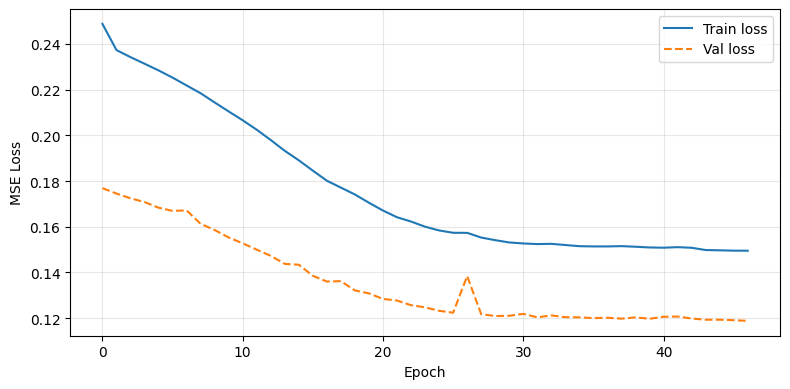

In [14]:
CKPT_PATH = OUT_DIR / "maritime_transformer_best.pt"

if CKPT_PATH.exists():
    # Poids du modèle
    ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True)
    model.load_state_dict(ckpt["model_state"])

    # Arrays numpy séparés
    seq_norm.means = np.load(OUT_DIR / "seq_norm_means.npy")
    seq_norm.stds  = np.load(OUT_DIR / "seq_norm_stds.npy")

    print(f"✅ Modèle chargé")
    print(f"   Epoch        : {ckpt['epoch']}")
    print(f"   Meilleure val: {ckpt['best_val']:.5f}")
    print(f"   Config       : {ckpt['config']}")

    # Courbes
    hist_path = OUT_DIR / "training_history.json"
    if hist_path.exists():
        import json, matplotlib.pyplot as plt
        with open(hist_path) as f:
            h = json.load(f)
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(h["train_loss"], label="Train loss")
        ax.plot(h["val_loss"],   label="Val loss", linestyle="--")
        ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
        ax.legend(); ax.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()
else:
    print("⚠️  Aucun checkpoint trouvé")

## 14. Extraction des embeddings

L'embedding d'un navire à un instant `t` = **moyenne sur les tokens de l'encodeur** (64D).

On enrichit ensuite chaque embedding avec les **features de scène** (49D) :
- Contexte temporel du navire (ce que le Transformer a appris)
- Contexte spatial et environnemental (voisins, météo, port)

Embedding final = **concat(Transformer_emb 64D, scène_49D) = 113D**


In [15]:
def extract_embeddings(model, seqs, seq_norm, batch_size=128):
    """
    Extrait les embeddings de l'encodeur pour toutes les séquences.
    Retourne : embeddings (N, D_MODEL), métadonnées (mmsi, t_pred)
    """
    model.eval()
    all_embs = []
    meta     = []

    for i in range(0, len(seqs), batch_size):
        batch = seqs[i:i+batch_size]
        contexts = torch.tensor(
            np.stack([seq_norm.transform_seq(s["context"]) for s in batch]),
            dtype=torch.float32, device=DEVICE)

        with torch.no_grad():
            enc_out   = model.encode(contexts)           # (B, 12, D_MODEL)
            embedding = enc_out.mean(dim=1).cpu().numpy() # (B, D_MODEL)

        all_embs.append(embedding)
        for s in batch:
            meta.append({"mmsi": s["mmsi"], "t_pred": s["t_pred"],
                         "t_start": s["t_start"]})

    embeddings = np.concatenate(all_embs, axis=0)
    meta_df    = pd.DataFrame(meta)
    print(f"✅ Embeddings extraits : {embeddings.shape}")
    return embeddings, meta_df


# ─── Extraction ───────────────────────────────────────────────────────────────
print("⏳ Extraction des embeddings...")
traj_embeddings, emb_meta = extract_embeddings(model, all_seqs, seq_norm)


⏳ Extraction des embeddings...
✅ Embeddings extraits : (145207, 64)


In [16]:
# ─── Construction des scènes pour les séquences ───────────────────────────────
# On construit une scène 49D pour chaque séquence (au timestamp t_pred)
print("⏳ Construction des scènes pour enrichir les embeddings...")

half   = pd.Timedelta(minutes=SCENE_DURATION_MIN/2)
scenes = []
scene_vectors = []

for idx, row in emb_meta.iterrows():
    if idx % 200 == 0: print(f"  [{idx}/{len(emb_meta)}]", end="\r")
    t_center = row["t_pred"]
    mmsi     = row["mmsi"]

    t_start  = t_center - half
    t_end    = t_center + half
    window   = ais_zone[
        (ais_zone["timestamp"] >= t_start) &
        (ais_zone["timestamp"] <= t_end)
    ]
    scene = build_scene(mmsi, t_center, window)
    if scene is not None:
        scenes.append(scene)
        scene_vectors.append(scene_to_vector(scene))
    else:
        scenes.append(None)
        scene_vectors.append(np.full(len(ALL_SCENE_NAMES), np.nan, dtype=np.float32))

scene_matrix = np.stack(scene_vectors)

# ─── Normalisation des scènes ─────────────────────────────────────────────────
scene_norm = SceneNormaliser()
scene_matrix_norm = scene_norm.fit_transform(scene_matrix)

# ─── Embeddings enrichis (Transformer 64D + Scène 49D = 113D) ────────────────
enriched_embeddings = np.concatenate([traj_embeddings, scene_matrix_norm], axis=1)
print(f"\n✅ Embeddings enrichis : {enriched_embeddings.shape}")
print(f"   Transformer : {traj_embeddings.shape[1]}D")
print(f"   Scène       : {scene_matrix_norm.shape[1]}D")
print(f"   Total       : {enriched_embeddings.shape[1]}D")


⏳ Construction des scènes pour enrichir les embeddings...
  [145200/145207]
✅ Embeddings enrichis : (145207, 113)
   Transformer : 64D
   Scène       : 49D
   Total       : 113D


## 15. Clustering HDBSCAN

In [17]:

from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

try:
    from hdbscan import HDBSCAN
    HDBSCAN_AVAILABLE = True
except ImportError:
    from sklearn.cluster import DBSCAN
    HDBSCAN_AVAILABLE = False

# ─── Imputation des NaN ───────────────────────────────────────────────────────
imputer = SimpleImputer(strategy="mean")
enriched_clean = imputer.fit_transform(enriched_embeddings)

# ─── PCA ─────────────────────────────────────────────────────────────────────
print("⏳ PCA...")
pca = PCA(n_components=30, random_state=42)
X_pca = pca.fit_transform(enriched_clean)
print(f"   Variance expliquée : {pca.explained_variance_ratio_.cumsum()[-1]*100:.1f}%")

# ─── HDBSCAN recalibré pour 145k points ──────────────────────────────────────
# Règle : min_cluster_size ≈ 0.1–0.5% du total
# 145k × 0.2% = ~290 points minimum par cluster → vise 50–200 clusters
print("⏳ Clustering HDBSCAN (recalibré)...")

MIN_CLUSTER_SIZE = 500    # ~0.35% de 145k → vise ~50-150 clusters
MIN_SAMPLES      = 50     # contrôle la robustesse au bruit

if HDBSCAN_AVAILABLE:
    clusterer = HDBSCAN(
        min_cluster_size=MIN_CLUSTER_SIZE,
        min_samples=MIN_SAMPLES,
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True,
        core_dist_n_jobs=-1,   # parallélisation
    )
else:
    clusterer = DBSCAN(eps=2.0, min_samples=MIN_SAMPLES)

cluster_labels = clusterer.fit_predict(X_pca)

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise    = (cluster_labels == -1).sum()

print(f"\n✅ Clustering terminé")
print(f"   Clusters : {n_clusters}")
print(f"   Bruit    : {n_noise} ({100*n_noise/len(cluster_labels):.1f}%)")
print(f"   Distribution taille clusters :")
sizes = pd.Series(cluster_labels[cluster_labels >= 0]).value_counts().sort_values()
print(f"     min={sizes.min()}  median={sizes.median():.0f}  max={sizes.max()}")
    
emb_meta["cluster"] = cluster_labels
emb_meta["behavior"] = [
    BEHAVIOR_LABELS.get(s.ego.behavior_code, "?") if s else "?"
    for s in scenes
]

⏳ PCA...
   Variance expliquée : 95.6%
⏳ Clustering HDBSCAN (recalibré)...

✅ Clustering terminé
   Clusters : 26
   Bruit    : 75199 (51.8%)
   Distribution taille clusters :
     min=516  median=1196  max=13730


In [18]:
# ─── Profil de chaque cluster ─────────────────────────────────────────────────
print("\nPROFIL DES CLUSTERS (comportements dominants) :")
print("="*60)
cluster_profiles = (
    emb_meta[emb_meta["cluster"] >= 0]
    .groupby("cluster")["behavior"]
    .value_counts(normalize=True)
    .rename("proportion")
    .reset_index()
    .sort_values(["cluster","proportion"], ascending=[True,False])
)
for cl in sorted(emb_meta["cluster"].unique()):
    if cl == -1: continue
    sub  = cluster_profiles[cluster_profiles["cluster"] == cl]
    n    = (emb_meta["cluster"] == cl).sum()
    top  = sub.iloc[0]
    print(f"  Cluster {cl:3d} ({n:4d} pts) → {top['behavior']} ({top['proportion']*100:.0f}%)")



PROFIL DES CLUSTERS (comportements dominants) :
  Cluster   0 ( 859 pts) → manœuvre (80%)
  Cluster   1 ( 668 pts) → ancré/amarré (98%)
  Cluster   2 (4550 pts) → ancré/amarré (100%)
  Cluster   3 (11430 pts) → ancré/amarré (100%)
  Cluster   4 (1762 pts) → ancré/amarré (56%)
  Cluster   5 (2923 pts) → ancré/amarré (100%)
  Cluster   6 (1914 pts) → ancré/amarré (100%)
  Cluster   7 (1040 pts) → ancré/amarré (100%)
  Cluster   8 ( 927 pts) → manœuvre (83%)
  Cluster   9 (1178 pts) → manœuvre (93%)
  Cluster  10 (1285 pts) → manœuvre (79%)
  Cluster  11 (11706 pts) → manœuvre (45%)
  Cluster  12 ( 799 pts) → ancré/amarré (100%)
  Cluster  13 (1194 pts) → ancré/amarré (100%)
  Cluster  14 (1198 pts) → ancré/amarré (100%)
  Cluster  15 ( 753 pts) → ancré/amarré (100%)
  Cluster  16 (1390 pts) → ancré/amarré (100%)
  Cluster  17 ( 559 pts) → ancré/amarré (100%)
  Cluster  18 (13730 pts) → ancré/amarré (100%)
  Cluster  19 ( 668 pts) → ancré/amarré (100%)
  Cluster  20 ( 949 pts) → ancré/am

⏳ Réduction 2D pour visualisation...
✅ Réduction 2D terminée


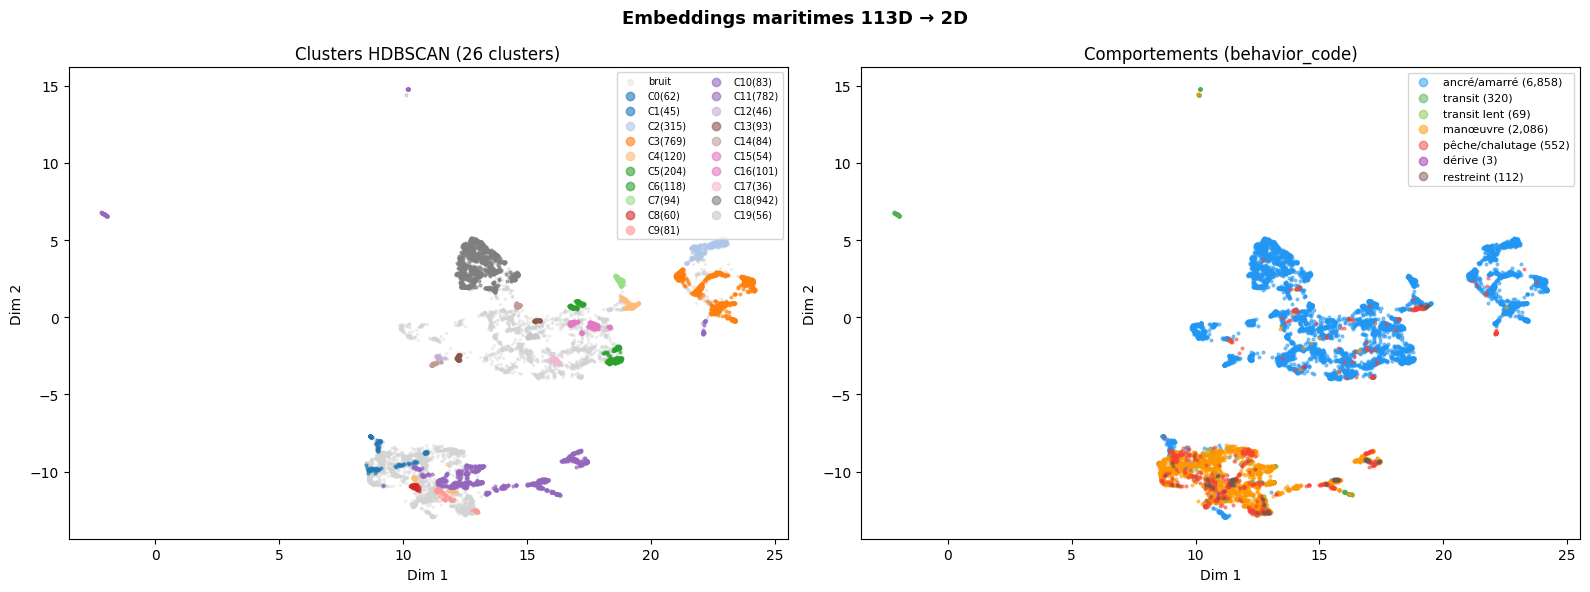

✅ Visualisation sauvegardée → outputs/clusters_visualization.png


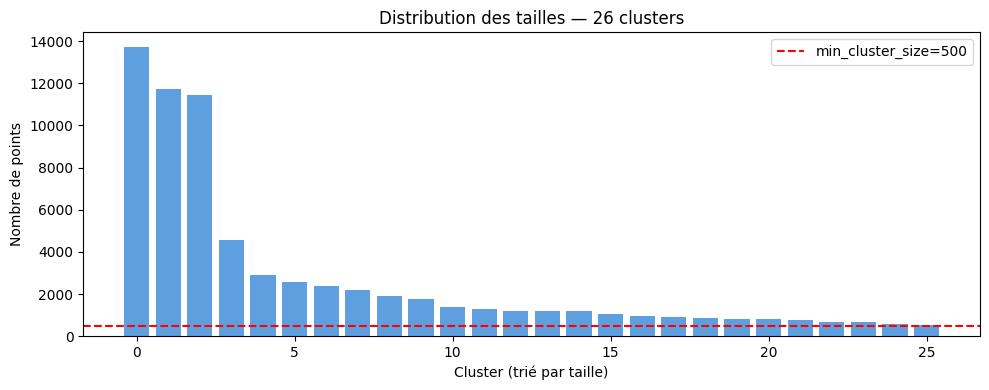

✅ Distribution sauvegardée → outputs/cluster_sizes.png


In [19]:
# pip install umap-learn matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    from sklearn.manifold import TSNE
    UMAP_AVAILABLE = False
    print("⚠️  umap-learn non installé — utilisation de t-SNE (pip install umap-learn)")

# ─── Réduction 2D pour visualisation (sur un échantillon de 10k max) ──────────
print("⏳ Réduction 2D pour visualisation...")
N_VIZ = min(10_000, len(X_pca))
viz_idx = np.random.choice(len(X_pca), N_VIZ, replace=False)
X_viz   = X_pca[viz_idx]
labels_viz = cluster_labels[viz_idx]
behav_viz  = emb_meta["behavior"].values[viz_idx]

if UMAP_AVAILABLE:
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
else:
    reducer = TSNE(n_components=2, random_state=42, perplexity=30)

X_2d = reducer.fit_transform(X_viz)
print("✅ Réduction 2D terminée")

# ─── Plot 1 : coloré par cluster ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Clusters (bruit en gris)
noise_mask    = labels_viz == -1
cluster_mask  = ~noise_mask
unique_clusters = np.unique(labels_viz[cluster_mask])
cmap = plt.cm.get_cmap("tab20", len(unique_clusters))

axes[0].scatter(X_2d[noise_mask, 0], X_2d[noise_mask, 1],
                c="lightgray", s=2, alpha=0.3, label="bruit")
for j, cl in enumerate(unique_clusters[:20]):  # top 20 clusters affichés
    mask = labels_viz == cl
    n    = mask.sum()
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=[cmap(j)], s=4, alpha=0.6, label=f"C{cl}({n})")
axes[0].set_title(f"Clusters HDBSCAN ({n_clusters} clusters)")
axes[0].legend(markerscale=3, fontsize=7, loc="upper right",
               ncol=2, bbox_to_anchor=(1.0, 1.0))
axes[0].set_xlabel("Dim 1"); axes[0].set_ylabel("Dim 2")

# ─── Plot 2 : coloré par comportement ─────────────────────────────────────────
BEH_COLORS = {
    "ancré/amarré":    "#2196F3",
    "transit":         "#4CAF50",
    "transit lent":    "#8BC34A",
    "manœuvre":        "#FF9800",
    "pêche/chalutage": "#F44336",
    "dérive":          "#9C27B0",
    "restreint":       "#795548",
    "?":               "#BDBDBD",
}
for beh, color in BEH_COLORS.items():
    mask = behav_viz == beh
    if mask.sum() == 0: continue
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=color, s=4, alpha=0.5, label=f"{beh} ({mask.sum():,})")
axes[1].set_title("Comportements (behavior_code)")
axes[1].legend(markerscale=3, fontsize=8, loc="upper right")
axes[1].set_xlabel("Dim 1"); axes[1].set_ylabel("Dim 2")

plt.suptitle("Embeddings maritimes 113D → 2D", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "clusters_visualization.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Visualisation sauvegardée → outputs/clusters_visualization.png")

# ─── Plot 3 : distribution des tailles de clusters ────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
sizes_plot = pd.Series(cluster_labels[cluster_labels >= 0]).value_counts().sort_values(ascending=False)
ax.bar(range(len(sizes_plot)), sizes_plot.values, color="#1976D2", alpha=0.7)
ax.axhline(y=MIN_CLUSTER_SIZE, color="red", linestyle="--", label=f"min_cluster_size={MIN_CLUSTER_SIZE}")
ax.set_xlabel("Cluster (trié par taille)")
ax.set_ylabel("Nombre de points")
ax.set_title(f"Distribution des tailles — {n_clusters} clusters")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "cluster_sizes.png", dpi=150)
plt.show()
print("✅ Distribution sauvegardée → outputs/cluster_sizes.png")

Distribution avant équilibrage :
behavior
ancré/amarré       99149
manœuvre           30333
pêche/chalutage     7998
transit             4784
restreint           1807
transit lent        1090
dérive                46
Name: count, dtype: int64

Après équilibrage : 14,943 séquences
behavior
manœuvre           3000
pêche/chalutage    3000
transit            3000
ancré/amarré       3000
restreint          1807
transit lent       1090
dérive               46
Name: count, dtype: int64

Variance expliquée (20D) : 87.4%

✅ Clustering équilibré
   Clusters : 47
   Bruit    : 7717 (51.6%)

PROFIL DES CLUSTERS :
  Cluster   0 (   55 pts) → pêche/chalutage (100%)
  Cluster   1 (  158 pts) → restreint (38%)
  Cluster   2 (   54 pts) → restreint (100%)
  Cluster   3 (  113 pts) → transit lent (40%)
  Cluster   4 (   92 pts) → restreint (38%)
  Cluster   5 (   51 pts) → transit (82%)
  Cluster   6 ( 1869 pts) → ancré/amarré (93%)
  Cluster   7 (  127 pts) → ancré/amarré (99%)
  Cluster   8 (  308 pts

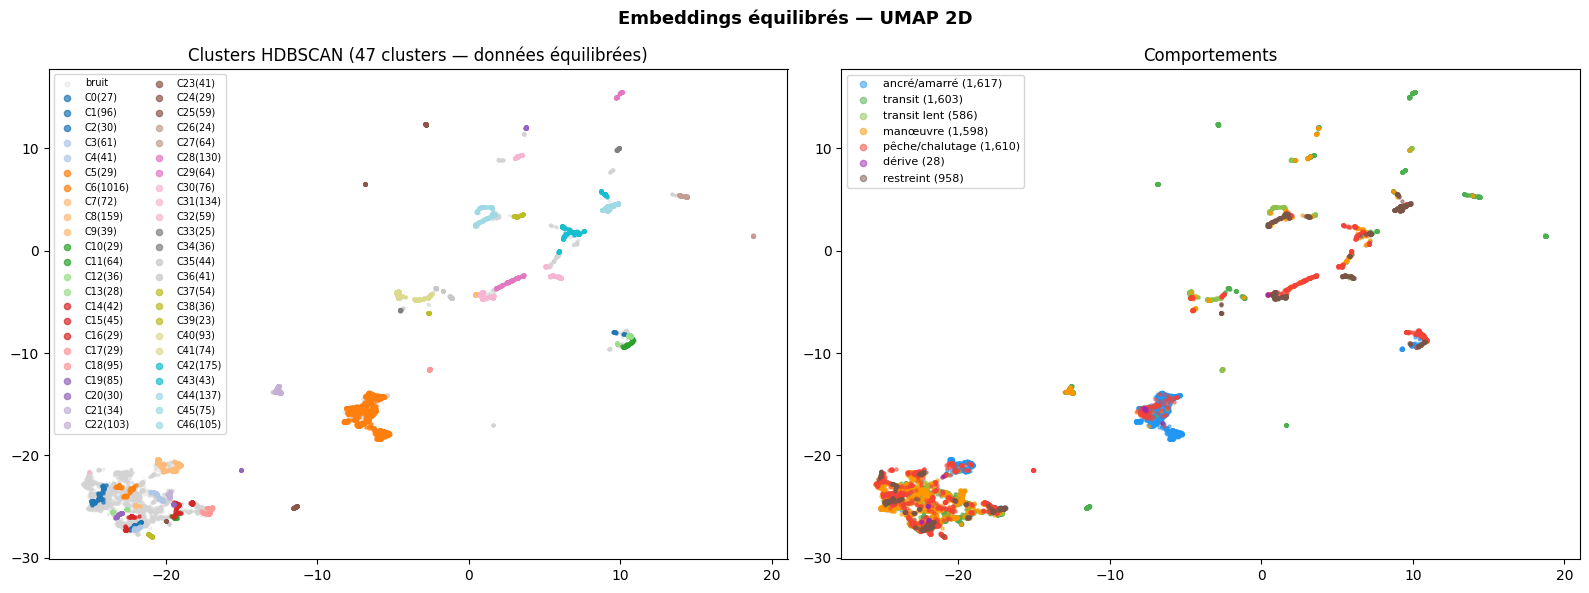

✅ Visualisation sauvegardée → outputs/clusters_balanced.png


In [20]:
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from hdbscan import HDBSCAN
except ImportError:
    from sklearn.cluster import DBSCAN

# ─── 1. Sous-échantillonnage équilibré par comportement ───────────────────────
# Le problème : ancré/amarré représente ~6858/10000 = 68% des données
# → On rééquilibre avant clustering

print("Distribution avant équilibrage :")
print(emb_meta["behavior"].value_counts())

# Garder MAX_PER_CLASS séquences par comportement
MAX_PER_CLASS = 3000

balanced_idx = []
for beh, grp in emb_meta.groupby("behavior"):
    if len(grp) > MAX_PER_CLASS:
        sampled = grp.sample(MAX_PER_CLASS, random_state=42).index
    else:
        sampled = grp.index
    balanced_idx.extend(sampled)

balanced_idx = sorted(balanced_idx)
print(f"\nAprès équilibrage : {len(balanced_idx):,} séquences")
print(emb_meta.loc[balanced_idx, "behavior"].value_counts())

# ─── 2. PCA sur données équilibrées ──────────────────────────────────────────
imputer = SimpleImputer(strategy="mean")
X_clean = imputer.fit_transform(enriched_embeddings[balanced_idx])

pca = PCA(n_components=20, random_state=42)   # 20D suffit (95% variance)
X_pca_bal = pca.fit_transform(X_clean)
print(f"\nVariance expliquée (20D) : {pca.explained_variance_ratio_.cumsum()[-1]*100:.1f}%")

# ─── 3. HDBSCAN avec paramètres adaptés aux données équilibrées ───────────────
# ~15k points équilibrés → min_cluster_size plus petit
MIN_CLUSTER_SIZE = 50   # ~0.7% de 15k
MIN_SAMPLES      = 10

clusterer_bal = HDBSCAN(
    min_cluster_size=MIN_CLUSTER_SIZE,
    min_samples=MIN_SAMPLES,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)
labels_bal = clusterer_bal.fit_predict(X_pca_bal)

n_clusters = len(set(labels_bal)) - (1 if -1 in labels_bal else 0)
n_noise    = (labels_bal == -1).sum()
print(f"\n✅ Clustering équilibré")
print(f"   Clusters : {n_clusters}")
print(f"   Bruit    : {n_noise} ({100*n_noise/len(labels_bal):.1f}%)")

# Réintégrer dans emb_meta
emb_meta["cluster"] = -2   # -2 = "non inclus dans l'équilibrage"
emb_meta.loc[balanced_idx, "cluster"] = labels_bal

# ─── 4. Profil des clusters ───────────────────────────────────────────────────
print("\nPROFIL DES CLUSTERS :")
print("="*55)
cluster_profiles = (
    emb_meta[emb_meta["cluster"] >= 0]
    .groupby("cluster")["behavior"]
    .value_counts(normalize=True)
    .rename("pct")
    .reset_index()
    .sort_values(["cluster","pct"], ascending=[True, False])
)
for cl in sorted(emb_meta[emb_meta["cluster"] >= 0]["cluster"].unique()):
    sub = cluster_profiles[cluster_profiles["cluster"] == cl]
    n   = (emb_meta["cluster"] == cl).sum()
    top = sub.iloc[0]
    print(f"  Cluster {cl:3d} ({n:5d} pts) → {top['behavior']} ({top['pct']*100:.0f}%)")

# ─── 5. Visualisation UMAP ───────────────────────────────────────────────────
try:
    import umap
    reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
except ImportError:
    from sklearn.manifold import TSNE
    reducer = TSNE(n_components=2, random_state=42, perplexity=30)

# Sous-échantillon pour la visu
N_VIZ    = min(8000, len(X_pca_bal))
viz_idx  = np.random.choice(len(X_pca_bal), N_VIZ, replace=False)
X_2d     = reducer.fit_transform(X_pca_bal[viz_idx])
lbl_viz  = labels_bal[viz_idx]
beh_viz  = emb_meta.loc[balanced_idx, "behavior"].values[viz_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot clusters
noise_m = lbl_viz == -1
axes[0].scatter(X_2d[noise_m,0], X_2d[noise_m,1], c="lightgray", s=3, alpha=0.3, label="bruit")
cmap = plt.cm.get_cmap("tab20", n_clusters)
for j, cl in enumerate(sorted(set(lbl_viz[~noise_m]))):
    m = lbl_viz == cl
    axes[0].scatter(X_2d[m,0], X_2d[m,1], c=[cmap(j)], s=5, alpha=0.7,
                    label=f"C{cl}({m.sum()})")
axes[0].set_title(f"Clusters HDBSCAN ({n_clusters} clusters — données équilibrées)")
axes[0].legend(markerscale=2, fontsize=7, ncol=2)

# Plot comportements
BEH_COLORS = {
    "ancré/amarré": "#2196F3", "transit": "#4CAF50",
    "transit lent": "#8BC34A", "manœuvre": "#FF9800",
    "pêche/chalutage": "#F44336", "dérive": "#9C27B0",
    "restreint": "#795548", "?": "#BDBDBD",
}
for beh, color in BEH_COLORS.items():
    m = beh_viz == beh
    if m.sum() == 0: continue
    axes[1].scatter(X_2d[m,0], X_2d[m,1], c=color, s=5, alpha=0.5,
                    label=f"{beh} ({m.sum():,})")
axes[1].set_title("Comportements")
axes[1].legend(markerscale=2, fontsize=8)

plt.suptitle("Embeddings équilibrés — UMAP 2D", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUT_DIR / "clusters_balanced.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Visualisation sauvegardée → outputs/clusters_balanced.png")

## 16. Détection d'anomalies

**Principe :** après entraînement, le modèle a appris la distribution "normale" des trajectoires.
Une anomalie = un embedding qui :
1. Tombe dans le cluster bruit HDBSCAN (-1), **OU**
2. A une erreur de prédiction élevée (le Transformer n'a pas su prédire la trajectoire)

On combine les deux signaux pour un score d'anomalie final.


In [21]:
def compute_prediction_errors(model, seqs, seq_norm, batch_size=128):
    """
    Calcule l'erreur de prédiction MSE pour chaque séquence.
    Une erreur élevée = trajectoire inhabituelle pour ce navire.
    """
    model.eval()
    errors = []
    for i in range(0, len(seqs), batch_size):
        batch   = seqs[i:i+batch_size]
        contexts = torch.tensor(
            np.stack([seq_norm.transform_seq(s["context"]) for s in batch]),
            dtype=torch.float32, device=DEVICE)
        targets  = torch.tensor(
            np.stack([seq_norm.transform_seq(
                np.concatenate([s["target"],
                                np.zeros((s["target"].shape[0], INPUT_DIM-TARGET_DIM))],
                               axis=1))[:, :TARGET_DIM]
                      for s in batch]),
            dtype=torch.float32, device=DEVICE)
        with torch.no_grad():
            preds, _ = model(contexts, targets)
            mse = ((preds - targets)**2).mean(dim=(1,2)).cpu().numpy()
        errors.extend(mse.tolist())
    return np.array(errors)

print("⏳ Calcul des erreurs de prédiction...")
pred_errors = compute_prediction_errors(model, all_seqs, seq_norm)

# ─── Score d'anomalie ─────────────────────────────────────────────────────────
# Normaliser l'erreur entre 0 et 1
err_min, err_max = pred_errors.min(), np.percentile(pred_errors, 99)
err_norm = np.clip((pred_errors - err_min) / (err_max - err_min + 1e-8), 0, 1)

# Score = 0.5 * erreur_prédiction + 0.5 * (cluster_bruit ? 1 : 0)
is_noise = (cluster_labels == -1).astype(float)
anomaly_score = 0.5 * err_norm + 0.5 * is_noise

emb_meta["pred_error"]    = pred_errors
emb_meta["anomaly_score"] = anomaly_score
emb_meta["is_anomaly"]    = anomaly_score > 0.7

n_anomalies = emb_meta["is_anomaly"].sum()
print(f"\n✅ Détection d'anomalies")
print(f"   Score > 0.7 : {n_anomalies} ({100*n_anomalies/len(emb_meta):.1f}%)")
print()
print("Top 10 anomalies :")
top_anomalies = emb_meta.sort_values("anomaly_score", ascending=False).head(10)
print(top_anomalies[["mmsi","t_pred","cluster","behavior","pred_error","anomaly_score"]].to_string(index=False))


⏳ Calcul des erreurs de prédiction...

✅ Détection d'anomalies
   Score > 0.7 : 2803 (1.9%)

Top 10 anomalies :
     mmsi                    t_pred  cluster behavior  pred_error  anomaly_score
565494000 2015-10-03 06:09:26+00:00       -1  transit    0.742739            1.0
565494000 2015-10-03 06:08:46+00:00       -1  transit    0.666793            1.0
226338000 2015-10-01 05:52:31+00:00       -1  transit    0.781858            1.0
565494000 2015-10-03 06:10:45+00:00       -1  transit    1.507359            1.0
226318000 2015-10-06 23:09:53+00:00       -2 manœuvre    1.036377            1.0
226318000 2015-10-06 23:09:47+00:00       -2 manœuvre    1.025194            1.0
226338000 2015-10-01 06:02:36+00:00       -1  transit    0.682954            1.0
226338000 2015-10-01 06:02:18+00:00       -2  transit    1.448802            1.0
226338000 2015-10-01 06:01:07+00:00       -1  transit    1.443943            1.0
226338000 2015-10-01 06:00:18+00:00       -2 manœuvre    1.454877            1

## 17. Sauvegarde des résultats

In [22]:
# Embeddings enrichis
np.save(OUT_DIR / "enriched_embeddings.npy", enriched_embeddings)
np.save(OUT_DIR / "traj_embeddings.npy",     traj_embeddings)
np.save(OUT_DIR / "scene_matrix_norm.npy",   scene_matrix_norm)

# Métadonnées avec clusters et scores
emb_meta.to_parquet(OUT_DIR / "embeddings_meta.parquet", index=False)

# Normalisateurs
np.save(OUT_DIR / "seq_norm_means.npy", seq_norm.means)
np.save(OUT_DIR / "seq_norm_stds.npy",  seq_norm.stds)
np.save(OUT_DIR / "scene_norm_means.npy", scene_norm.means_)
np.save(OUT_DIR / "scene_norm_stds.npy",  scene_norm.stds_)

print("✅ Résultats sauvegardés dans outputs/")
print(f"   enriched_embeddings.npy  → {enriched_embeddings.shape}")
print(f"   traj_embeddings.npy      → {traj_embeddings.shape}")
print(f"   embeddings_meta.parquet  → {len(emb_meta)} lignes")
print()
print("Colonnes disponibles dans embeddings_meta :")
print(list(emb_meta.columns))


✅ Résultats sauvegardés dans outputs/
   enriched_embeddings.npy  → (145207, 113)
   traj_embeddings.npy      → (145207, 64)
   embeddings_meta.parquet  → 145207 lignes

Colonnes disponibles dans embeddings_meta :
['mmsi', 't_pred', 't_start', 'cluster', 'behavior', 'pred_error', 'anomaly_score', 'is_anomaly']


## 18. Résumé du pipeline & prochaines étapes

### Ce qu'on a construit

| Étape | Output | Dimensions |
|---|---|---|
| Séquences AIS | `all_seqs` | (N, 12, 7) contexte + (N, 30, 5) cible |
| Transformer SSL | `maritime_transformer.pt` | 64D embeddings |
| Scènes maritimes | `scene_matrix_norm` | 49D par séquence |
| Embeddings enrichis | `enriched_embeddings.npy` | 113D |
| Clusters | `embeddings_meta["cluster"]` | N clusters + bruit |
| Anomalies | `embeddings_meta["anomaly_score"]` | score 0–1 |



